# Executive Summary

###The Dataset is obtained from UC Irvine ML Repository. The dataset has information related to diabetics patients. It has 101766 samples and 50 features. The main goal of the project is to classify the readmission of the patients to the hospital.

###Intially Exploratory data analysis was performed and the data was cleaned. The 'weight' feature plays a crucial role in diabtetics patients, though it had 90 percent missing values, we had to retain it by imputing the missing values. Parallely feature engineering was also perfromed. Then we scaled down the entire dataset, so that the model would provide equal importance to all features.

###Next, we split the data into train and validation sets, then we train 8 Machine Learning models on the training data and then classified the output on the test data. By observing and comparing the results of these process, finally XGBoost model was concluded as the best performing model with accuarcy of 64 percentage.

### Import the required libraries

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, f1_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier

### Load the Dataset

In [3]:
data_df = pd.read_csv('/content/sample_data/diabetic_data.csv')

In [4]:
#data_df

# Data Pre-Processing

In [5]:
data_df.shape

(101766, 50)

In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
data_df.shape

(101766, 50)

In [8]:
pd.pandas.set_option('display.max_rows', None) # This is used to display all rows in the output

In [9]:
data_df['weight'].value_counts() # Through this code we can understand the distribution of categories in each feature

?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: weight, dtype: int64

In [10]:
data_df['race'].value_counts()

Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: race, dtype: int64

In [11]:
# Here we replace '?' as 'Other'
data_df['race'] = data_df['race'].apply(lambda x: 'Other' if x == '?' else x)

In [12]:
data_df['race'].value_counts()

Caucasian          76099
AfricanAmerican    19210
Other               3779
Hispanic            2037
Asian                641
Name: race, dtype: int64

In [13]:
data_df['gender'].value_counts()

Female             54708
Male               47055
Unknown/Invalid        3
Name: gender, dtype: int64

In [14]:
data_df['readmitted'].value_counts()

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

In [15]:
# Here we replace the 'Unknown/Invalid' values with the calculated mode

mode_gender = data_df[data_df['gender'] != 'Unknown/Invalid']['gender'].mode()[0]

data_df.loc[data_df['gender'] == 'Unknown/Invalid', 'gender'] = mode_gender

In [16]:
data_df['gender'].value_counts()

Female    54711
Male      47055
Name: gender, dtype: int64

In [17]:
# Eliminate rows where the 'weight' column contains '>200', this may act as an outlier
data_df = data_df[data_df['weight'] != '>200']

In [18]:
# Here we are splitting up the range of weight values.
def transform_weight(w):
    if w == '?':
        return w
    else:
        w_str = str(w)  # convert to string
        if '-' not in w_str:
            return np.nan
        else:
            try:
                a, b = w_str[1:-1].split('-')
                return np.random.uniform(float(a), float(b))
            except ValueError:
                return np.nan


# Now apply the function to the "weight" column
data_df['weight'] = data_df['weight'].apply(transform_weight)

In [19]:
weight_counts = data_df['weight'].value_counts()
len(weight_counts)

3195

In [20]:
data_df['weight'].info()

<class 'pandas.core.series.Series'>
Int64Index: 101763 entries, 0 to 101765
Series name: weight
Non-Null Count   Dtype 
--------------   ----- 
101763 non-null  object
dtypes: object(1)
memory usage: 1.6+ MB


In [21]:
data_df.shape

(101763, 50)

In [22]:
# Now we define a function that generates a random age within the give age range

def generate_age_from_range(age_range_str):
    # remove the brackets from the range and then convert them into a tuple
    age_range_str = age_range_str.replace('[', '').replace(')', '')
    age_range = tuple(map(int, age_range_str.split('-')))

    new_age = np.random.randint(age_range[0], age_range[1])

    return new_age

In [23]:
# apply the function to the 'age_range' column to generate a new 'age' column
data_df['age'] = data_df['age'].apply(generate_age_from_range)

In [24]:
len(data_df['age'].value_counts())

100

In [25]:
# Here we replace '?' with '' in 'weight' column

data_df['weight'] = data_df['weight'].replace('?', '')

In [26]:
# We create a new dataset inorder to use it for imputing the 'weight' feature
data_df.to_csv('diabetic_datanew.csv', index=False)

In [27]:
from sklearn.model_selection import train_test_split

# Load the data
diabetics_df = pd.read_csv('diabetic_datanew.csv')

In [28]:
diabetics_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,6,NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,16,NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,29,NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,30,NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,40,NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO




---


### Since 'weight' feature had 98569 missing values, it was necessary to impute it. After refering other resources it was concluded that weight is an important feature, and it has a major impact in the classification of our response variable. Therefore we consider features sunch as 'race', 'age', 'gender' and known 'weight' values, using these features we train a Random Forest Regressor and we predict the weight. Using these predictions we impute the 'weight' feature in our dataset.

In [29]:
# One-hot encode both 'race' and 'gender' columns as they have categorical values
race_encoded = pd.get_dummies(diabetics_df['race'], prefix='race')
gender_encoded = pd.get_dummies(diabetics_df['gender'], prefix='gender')

In [30]:
# Here we combine the encoded columns with the numerical columns
encoded_df = pd.concat([diabetics_df[['weight', 'age']], race_encoded, gender_encoded], axis=1)

In [31]:
# Now we split the dataset into two parts: missing weight and known weight
missing_weight = encoded_df[encoded_df['weight'].isnull()]
known_weight = encoded_df[encoded_df['weight'].notnull()]

In [32]:
# Now by using the known weight values we split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    known_weight.drop('weight', axis=1),
    known_weight['weight'],
    test_size=0.2,
    random_state=42
)

In [33]:
# Train a Random Forest Regressor model on the train data
rfr_model = RandomForestRegressor()
rfr_model.fit(X_train, y_train)

RandomForestRegressor()

In [34]:
# Now we evaluate the model using the testing set
y_predrfr = rfr_model.predict(X_test)
print('Mean Squared Error:', mean_squared_error(y_test, y_predrfr))
print('R2 Score:', r2_score(y_test, y_predrfr))

Mean Squared Error: 649.7907624565464
R2 Score: 0.02886163197867364


In [35]:
# Here we fill the missing weight values using the trained model
missing_weight_pred = rfr_model.predict(missing_weight.drop('weight', axis=1))

In [36]:
# Now we clip the predictions to be within the range [5, 100]
missing_weight_pred = np.clip(missing_weight_pred, 5, 100)
diabetics_df.loc[diabetics_df['weight'].isnull(), 'weight'] = missing_weight_pred

In [37]:
# Here we check the weight for an age of 15 year
age = 15
sample_input = np.zeros(X_train.shape[1])
sample_input[0] = age

predicted_weight = rfr_model.predict([sample_input])[0]
print(f"Predicted weight for age {age}: {predicted_weight:.2f} kg")

Predicted weight for age 15: 53.94 kg


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [38]:
diabetics_df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,6,45.095404,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,16,55.898504,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,29,87.226280,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,30,100.000000,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,40,91.826071,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,58,91.159531,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,69,99.066250,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,72,98.101394,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,89,72.449809,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,97,53.901247,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [39]:
diabetics_df.to_csv('diabetic_datanew.csv', index=False)

In [40]:
diabetics_df.describe() # this code enables us to view some statistical values of the dataset

,encounter_id,patient_nbr,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017630e+05,1.017630e+05,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,1.652009e+08,5.433063e+07,65.471900,85.113925,2.023987,3.715702,5.754302,4.395920,43.095103,1.339770,16.021894,0.369329,0.197842,0.635555,7.422590
std,1.026400e+08,3.869653e+07,16.202317,13.068950,1.445363,5.280229,4.063984,2.985105,19.674310,1.705817,8.127655,1.267232,0.930485,1.262873,1.933611
min,1.252200e+04,1.350000e+02,0.000000,0.636032,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496232e+07,2.341323e+07,55.000000,78.990264,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523883e+08,4.550514e+07,67.000000,87.034765,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302698e+08,8.754619e+07,77.000000,94.474927,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,99.000000,193.988677,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


# Feature Engineering

### So, now we create some plots inorder to visualize the relationship betweem the features.

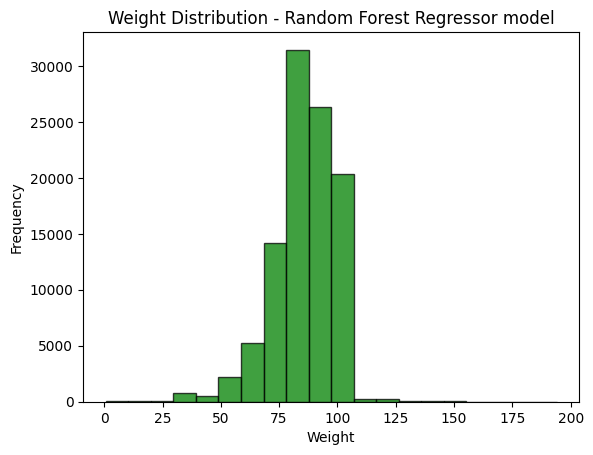

In [41]:
# Plot histogram for the 'weight' column
plt.hist(diabetics_df['weight'], bins=20, edgecolor='black', color='green', alpha=0.75)
sns.set(rc={'figure.figsize':(8,6)})
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Weight Distribution - Random Forest Regressor model')
plt.show()

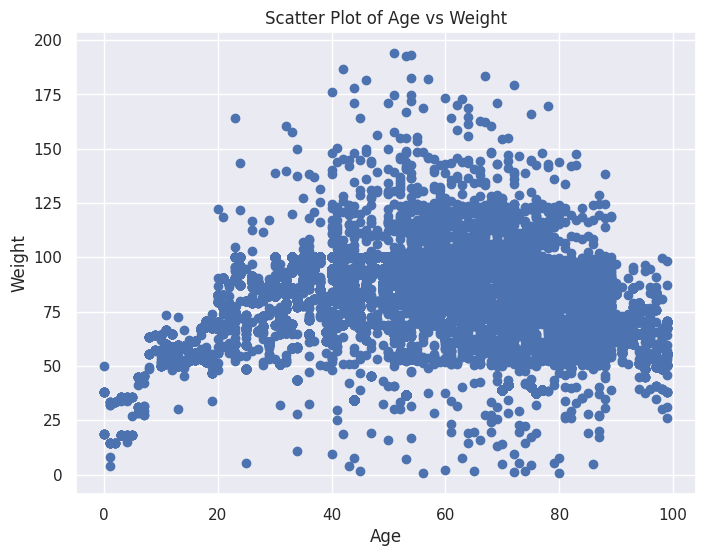

In [42]:
# Here we plot a scatter plot
plt.scatter(diabetics_df['age'], diabetics_df['weight'])
sns.set(rc={'figure.figsize':(8,6)})
plt.xlabel('Age')
plt.ylabel('Weight')
plt.title('Scatter Plot of Age vs Weight')
plt.show()

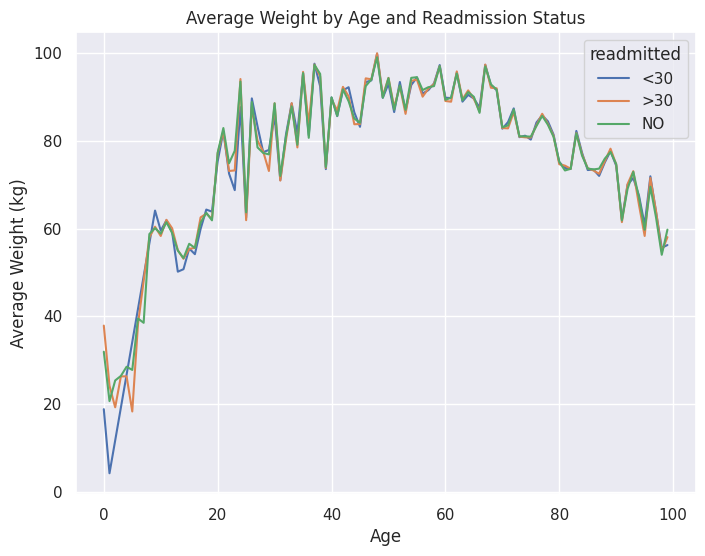

In [43]:
# Now we group the data by 'age' and 'readmitted' inorder to calculate the mean weight for each group

readmitted_weight = diabetics_df.groupby(['age', 'readmitted'])['weight'].mean().reset_index()

# Create the line plot
sns.lineplot(x='age', y='weight', hue='readmitted', data=readmitted_weight)
sns.set(rc={'figure.figsize':(8,6)})
plt.title("Average Weight by Age and Readmission Status")
plt.xlabel("Age")
plt.ylabel("Average Weight (kg)")
plt.show()

Text(0.5, 1.0, 'Class Distribution \n')

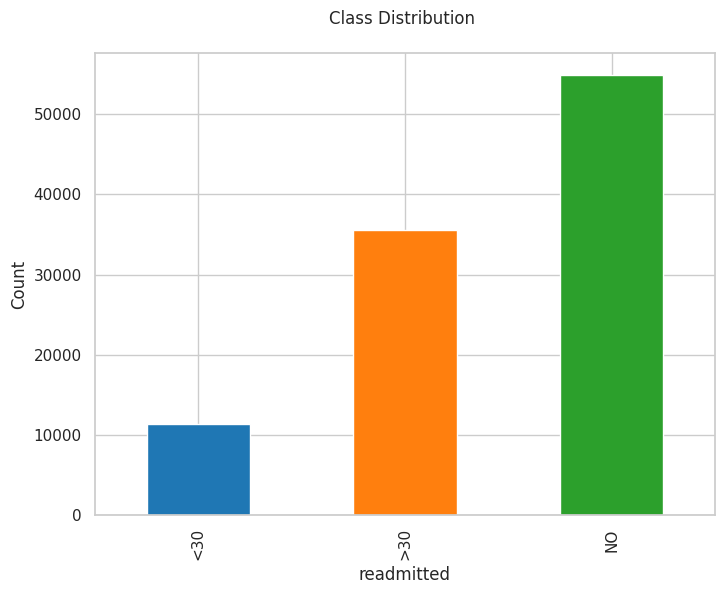

In [44]:
# Here we visualize the distribution of the 'readmitted' feature.

sns.set(rc={'figure.figsize':(8,6)})
sns.set_style("whitegrid")
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

data_df.groupby('readmitted').size().plot(kind='bar', color=colors)
plt.ylabel('Count')
plt.title('Class Distribution \n', size = 12)

In [45]:
# Now we create another column and consider it as 2 class problem, Label the <30 and >30 as YES and "N0" as No.

def check_label(text):
    if text == '>30' or text =='<30':
        return 'Yes'
    else:
        return 'No'

diabetics_df['readmitted_2'] =diabetics_df['readmitted'].apply(check_label)

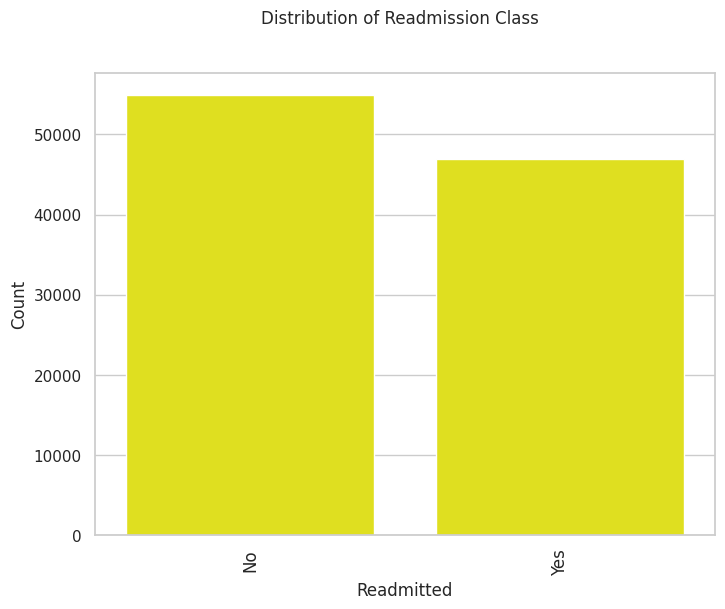

In [46]:
sns.countplot(x='readmitted_2',   data= diabetics_df, color='yellow')
plt.xlabel('Readmitted', size = 12)
plt.xticks(rotation=90, size = 12)
plt.ylabel('Count', size = 12)
plt.title('Distribution of Readmission Class  \n\n', size = 12)
plt.show()

In [47]:
diabetics_df['readmitted_2'].value_counts()

No     54864
Yes    46899
Name: readmitted_2, dtype: int64

### By visualizing the below displayed plot we can observe that people aged above 50 are the ones that have high ferquency of readmission

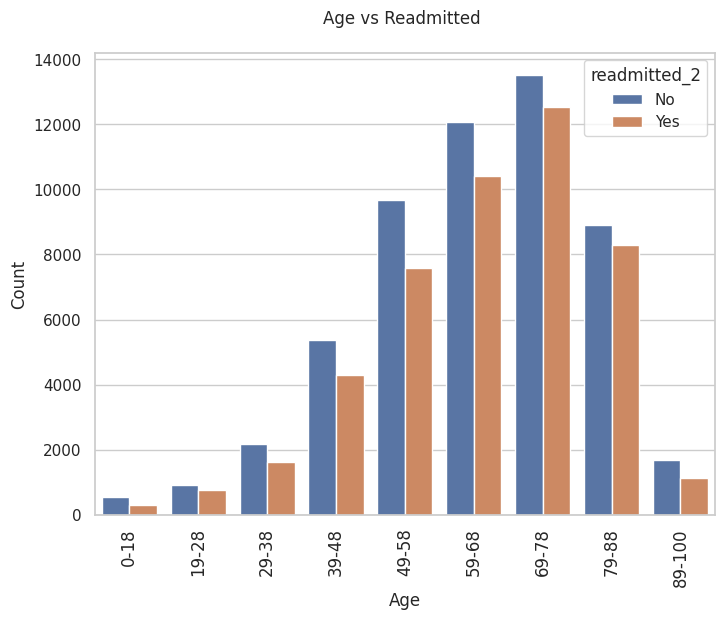

In [48]:
# Define the age groups
bins = [0, 19, 29, 39, 49, 59, 69, 79, 89, 100]
labels = ['0-18', '19-28', '29-38', '39-48', '49-58', '59-68', '69-78', '79-88', '89-100']
age_groups = pd.cut(diabetics_df['age'], bins=bins, labels=labels)

# Plot countplot with age groups
ageax = sns.countplot(x=age_groups, hue="readmitted_2", data=diabetics_df)
plt.xlabel('Age', size=12)
plt.xticks(rotation=90, size=12)
plt.ylabel('Count', size=12)
plt.title('Age vs Readmitted \n', size=12)
plt.show()

### If features are highly co-related then they tend to give the same information to the model, so we try to identify the higly co-related features and eliminate one of them

<ipython-input-49-dc4cb931e5d8>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = diabetics_df.corr()


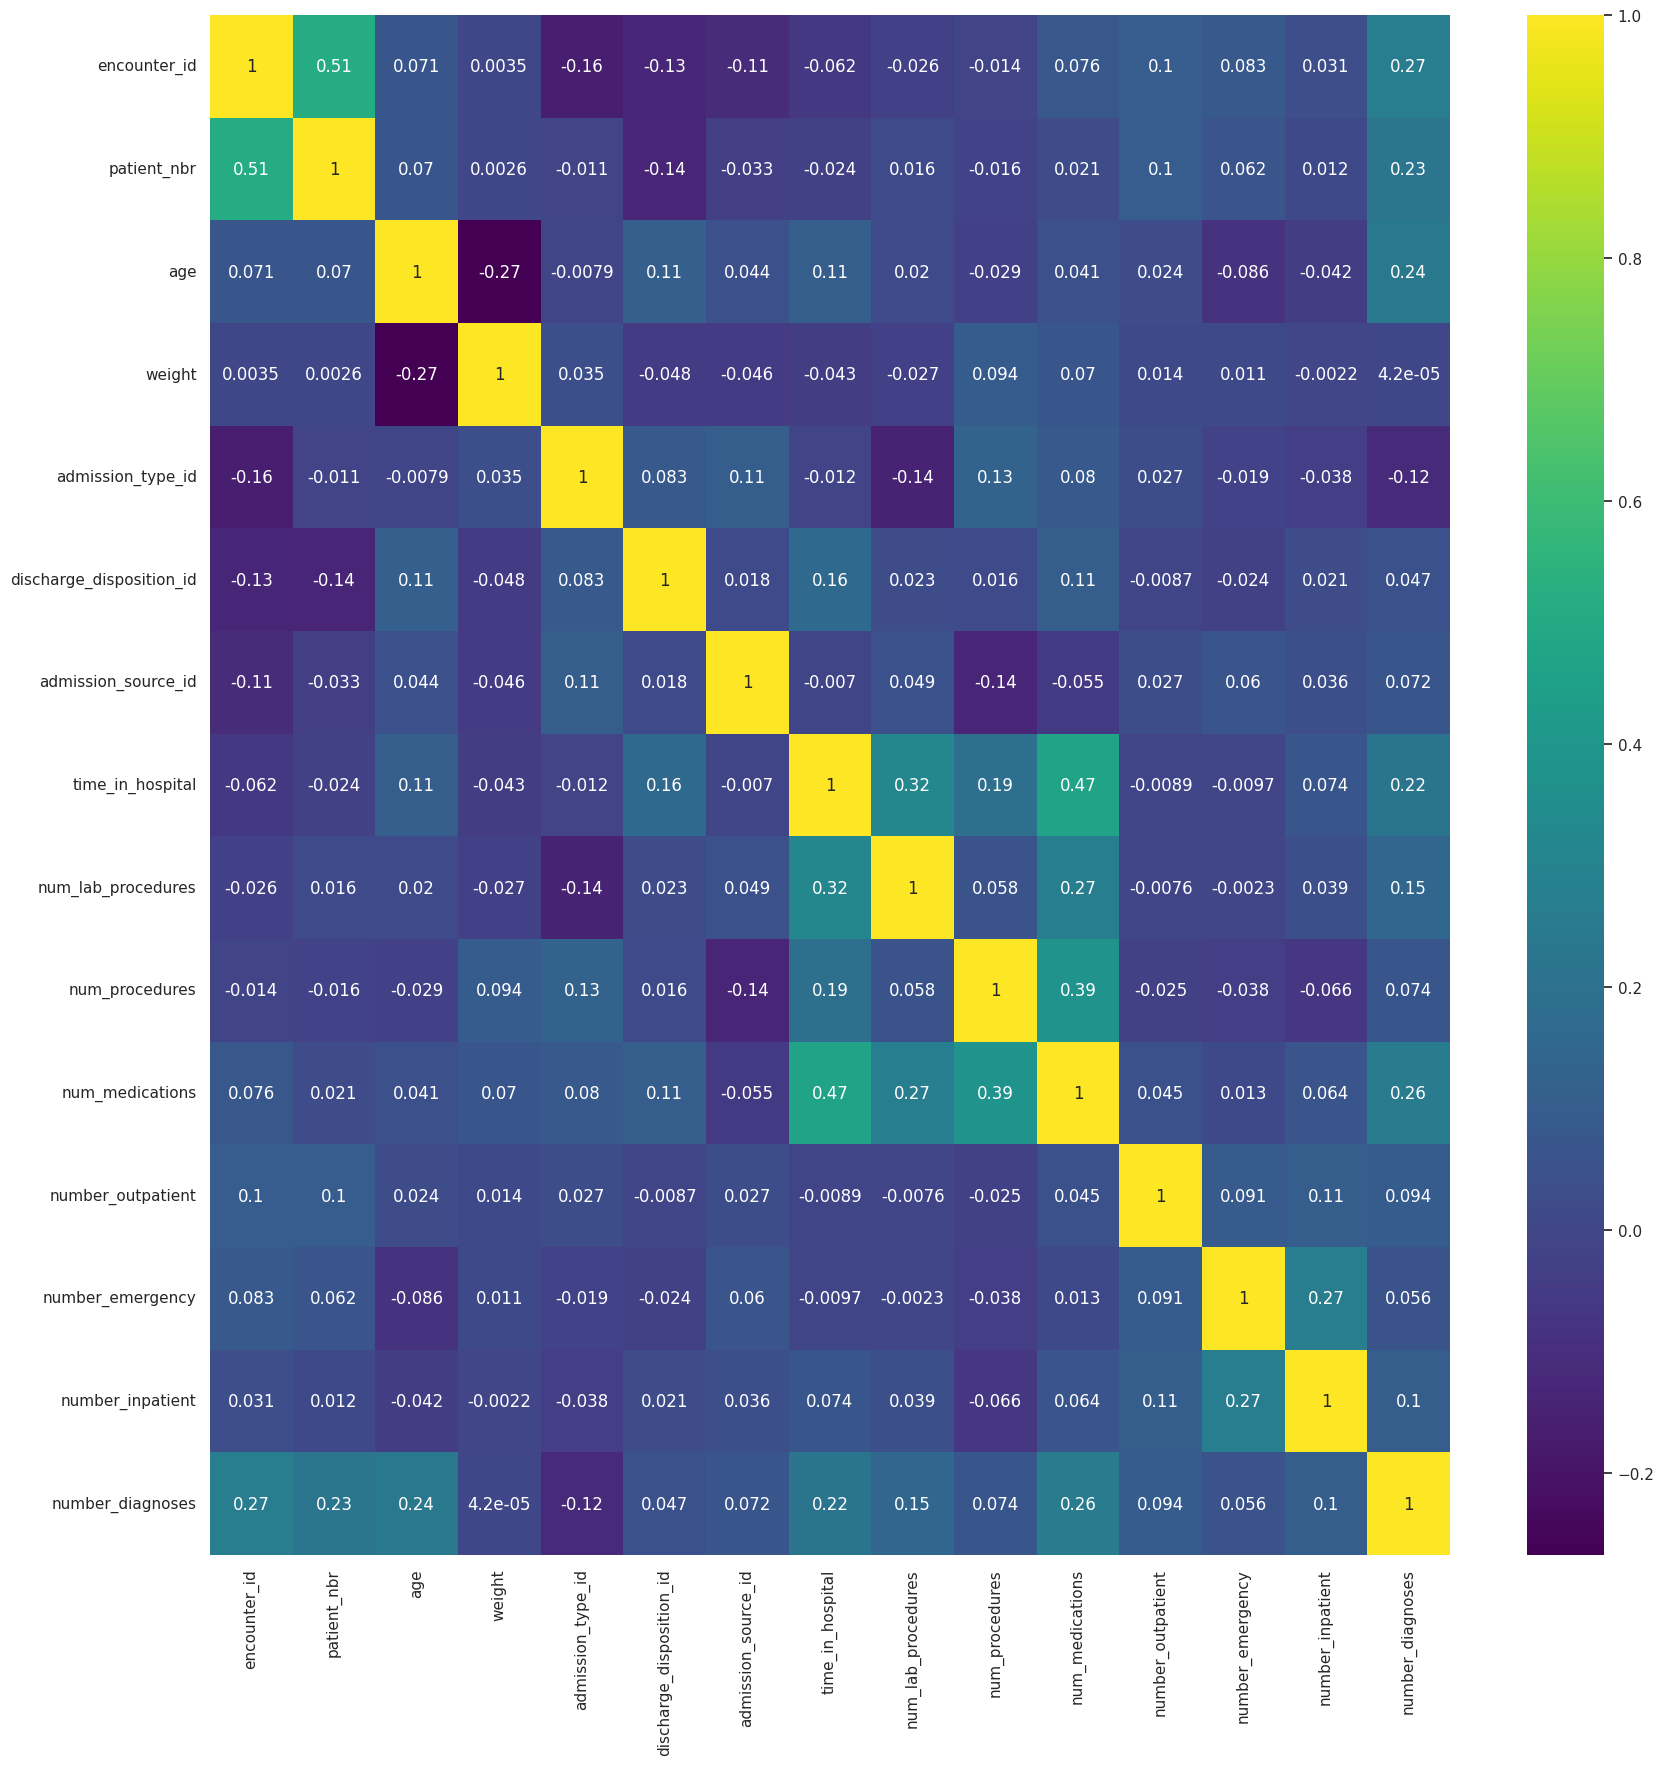

In [49]:
#get correlations of each features in dataset
corrmat = diabetics_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(diabetics_df[top_corr_features].corr(),annot=True,cmap="viridis")

### Through the below obtained results we can observe that there are no features that are highly correlated.

In [50]:
#finding correlated features
def corelation(diabetics_df, threshold):
  col_corr = set() #all correlated columns
  corr_matrix = diabetics_df.corr()
  for r in range (len(corr_matrix.columns)):
    for s in range(r):
      if (corr_matrix.iloc[r,s]) > threshold:
        colname = corr_matrix.columns[r]
        col_corr.add(colname)
  return col_corr

In [51]:
corr_features = corelation(diabetics_df, 0.8)
len(set(corr_features))

<ipython-input-50-62f75bf0151b>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = diabetics_df.corr()


0

In [52]:
diabetics_df['medical_specialty'].value_counts()

?                                       49946
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediatrics                                254
Hematology/Oncology               

###The feature 'medical_specialty' has 49946 missing values, it is not possible to impute all those values accuractely, so it's better to drop it.

In [53]:
diabetics_df.drop(columns =['medical_specialty'], inplace = True)

### All of these features do not have a significant impact on the response variable, therefore it is better to drop them.

In [54]:
diabetics_df.drop(columns = ['acetohexamide', 'payer_code','tolbutamide', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
                   'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                   'metformin-pioglitazone', 'encounter_id', 'patient_nbr', 'readmitted'], inplace = True)

In [55]:
diabetics_df.shape

(101763, 36)

### Now we eliminate the rows in which the features 'diag1', 'diag2', and 'diag3', have '?' as values.

In [56]:
diabetics_df = diabetics_df[~((diabetics_df['diag_1'] == "?") | (diabetics_df['diag_2'] == "?") | (diabetics_df['diag_3'] == "?"))]

In [57]:
diabetics_df.shape

(100241, 36)

In [58]:
for col in diabetics_df.columns:
    print(col,diabetics_df[col].unique())

race ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
gender ['Female' 'Male']
age [16 29 30 40 58 69 72 89 97 44 47 83 64 61 52 53 70 75 54 71 84 73 50 57
 21 63 78 76 77 66 65 74 41 55 43 59 68 79 48 87 85 56 91 80 62 67 39 36
 60 42 49 32 25 82 86 45 35 81 28 33 13 88 51 18 27  5 17 20 37 92 46 12
 34 38 19 31  6 90 94 24 95 10 23 96  3  9 26 15 98 22  8 11 93  1  2 99
 14  4  0  7]
weight [ 55.89850374  87.22627987 100.         ...  83.37788321  77.719615
 161.50698924]
admission_type_id [1 2 3 6 4 5 8 7]
discharge_disposition_id [ 1  3  6  2  5 11  7 25 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
admission_source_id [ 7  2  4  1  5  6 20  3 17  8  9 14 10 22 11 25 13]
time_in_hospital [ 3  2  1  4  5 13 12  9  7 10  6 11  8 14]
num_lab_procedures [ 59  11  44  51  31  70  73  68  33  47  62  60  55  49  75  45  29  35
  42  66  36  19  64  25  53  52  87  27  37  46  41  28  48  72  10   2
  65  67  40  54  58  57  43  32  83  34  39  69  38  56  22  96  78  

### As a reslut of the above code block we can observe that features 'diag1', 'diag2', and 'diag3' have a lot of unique values.


---


### Now we impute those features by reffering the paper enlisted in the dataset webpage. In the paper they are mentioned as ICD9 codes.

### Paper link : "https://www.hindawi.com/journals/bmri/2014/781670/"

### At first we convert these numerical values into categorical values based on the grouping mentioned in the paper. Once this is completed, we then perform label encoding on these catgegorical features.

In [59]:
diag_cols = ['diag_1','diag_2','diag_3']
for col in diag_cols:
    diabetics_df[col] = diabetics_df[col].str.replace('E','-')
    diabetics_df[col] = diabetics_df[col].str.replace('V','-')
    condition = diabetics_df[col].str.contains('250', na=False)
    diabetics_df.loc[condition,col] = '250'

diabetics_df[diag_cols] = diabetics_df[diag_cols].astype(float)

In [60]:
# diagnosis grouping based on ICD9 codes given in the paper
for col in diag_cols:
    diabetics_df['temp']='Others'
    diabetics_df.loc[diabetics_df[col]==250,'temp']='Diabetes'
    diabetics_df.loc[(diabetics_df[col]>=390) & (diabetics_df[col]<=458) | (diabetics_df[col]==785),'temp']='Circulatory'
    diabetics_df.loc[(diabetics_df[col]>=460) & (diabetics_df[col]<=519) | (diabetics_df[col]==786),'temp']='Respiratory'
    diabetics_df.loc[(diabetics_df[col]>=520) & (diabetics_df[col]<=579) | (diabetics_df[col]==787),'temp']='Digestive'
    diabetics_df.loc[(diabetics_df[col]>=580) & (diabetics_df[col]<=629) | (diabetics_df[col]==788),'temp']='Genitourinary'
    diabetics_df.loc[(diabetics_df[col]>=800) & (diabetics_df[col]<=999),'temp']='Injury'
    diabetics_df.loc[(diabetics_df[col]>=710) & (diabetics_df[col]<=739),'temp']='Muscoloskeletal'
    diabetics_df.loc[(diabetics_df[col]>=140) & (diabetics_df[col]<=239),'temp']='Neoplasms'
    diabetics_df.loc[diabetics_df[col]<0,'temp']='External'
    diabetics_df[col]=diabetics_df['temp']
    diabetics_df.drop('temp',axis=1,inplace=True)
for col in diag_cols:
    print(col,diabetics_df[col].unique())

diag_1 ['Others' 'Neoplasms' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury'
 'Muscoloskeletal' 'Digestive' 'External' 'Genitourinary']
diag_2 ['Diabetes' 'Neoplasms' 'Circulatory' 'Respiratory' 'Others' 'Injury'
 'Muscoloskeletal' 'Genitourinary' 'Digestive' 'External']
diag_3 ['Others' 'External' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury'
 'Neoplasms' 'Genitourinary' 'Muscoloskeletal' 'Digestive']


In [61]:
diabetics_df['diag_1'].value_counts()

Circulatory        30212
Others             16433
Respiratory        14304
Digestive           9363
Diabetes            8134
Injury              6836
Genitourinary       5073
Muscoloskeletal     4858
Neoplasms           3390
External            1638
Name: diag_1, dtype: int64

In [62]:
diabetics_df['diag_2'].value_counts()

Circulatory        31748
Others             23805
Diabetes           12148
Respiratory        10864
Genitourinary       8348
Digestive           4143
Neoplasms           2542
External            2479
Injury              2404
Muscoloskeletal     1760
Name: diag_2, dtype: int64

In [63]:
diabetics_df['diag_3'].value_counts()

Circulatory        30176
Others             24218
Diabetes           17129
Respiratory         7352
Genitourinary       6675
External            5053
Digestive           3928
Injury              1943
Muscoloskeletal     1914
Neoplasms           1853
Name: diag_3, dtype: int64

### By referring IDS_mapping dataset, the feature '**admission_type_id**' has multiple categories that refer to admission type being not available. Therefore it's ideal to group them into a single category.

In [64]:
diabetics_df['admission_type_id'] = diabetics_df['admission_type_id'].replace({6: 5, 8: 5})

In [65]:
diabetics_df['admission_type_id'].unique()

array([1, 2, 3, 5, 4, 7])

### The features '**admission_source_id**' and '**discharge_disposition_id**' also has many classes that refer to not available or null, so we group them into one.

In [66]:
# Impute 'admission_source_id'
diabetics_df['admission_source_id'] = diabetics_df['admission_source_id'].replace({15: 9, 17: 9, 20: 9, 21: 9})

In [67]:
diabetics_df['admission_source_id'].unique()

array([ 7,  2,  4,  1,  5,  6,  9,  3,  8, 14, 10, 22, 11, 25, 13])

In [68]:
# Impute 'dischage_disposition_id' ]
diabetics_df['discharge_disposition_id'] = diabetics_df['discharge_disposition_id'].replace({25: 18, 26: 18})
diabetics_df['discharge_disposition_id'].unique()

array([ 1,  3,  6,  2,  5, 11,  7, 18, 10,  4, 14,  8, 13, 12, 16, 17, 22,
       23,  9, 20, 15, 24, 28, 19, 27])

In [69]:
diabetics_df.head(5)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide,pioglitazone,rosiglitazone,acarbose,miglitol,insulin,glyburide-metformin,change,diabetesMed,readmitted_2
1,Caucasian,Female,16,55.898504,1,1,7,3,59,0,...,No,No,No,No,No,Up,No,Ch,Yes,Yes
2,AfricanAmerican,Female,29,87.226280,1,1,7,2,11,5,...,No,No,No,No,No,No,No,No,Yes,No
3,Caucasian,Male,30,100.000000,1,1,7,2,44,1,...,No,No,No,No,No,Up,No,Ch,Yes,No
4,Caucasian,Male,40,91.826071,1,1,7,1,51,0,...,No,No,No,No,No,Steady,No,Ch,Yes,No
5,Caucasian,Male,58,91.159531,2,1,2,3,31,6,...,No,No,No,No,No,Steady,No,No,Yes,Yes


In [70]:
diabetics_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100241 entries, 1 to 101762
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      100241 non-null  object 
 1   gender                    100241 non-null  object 
 2   age                       100241 non-null  int64  
 3   weight                    100241 non-null  float64
 4   admission_type_id         100241 non-null  int64  
 5   discharge_disposition_id  100241 non-null  int64  
 6   admission_source_id       100241 non-null  int64  
 7   time_in_hospital          100241 non-null  int64  
 8   num_lab_procedures        100241 non-null  int64  
 9   num_procedures            100241 non-null  int64  
 10  num_medications           100241 non-null  int64  
 11  number_outpatient         100241 non-null  int64  
 12  number_emergency          100241 non-null  int64  
 13  number_inpatient          100241 non-null  i

# Transform the categorical features

In [71]:
le = LabelEncoder()

categorical_features =['race', 'weight','gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
       'glyburide-metformin', 'change', 'diabetesMed', 'readmitted_2']

for i in categorical_features:
    diabetics_df[i] = le.fit_transform(diabetics_df[i])

In [72]:
diabetics_df.head(5)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide,pioglitazone,rosiglitazone,acarbose,miglitol,insulin,glyburide-metformin,change,diabetesMed,readmitted_2
1,2,0,16,453,0,0,6,3,59,0,...,1,1,1,1,1,3,1,0,1,1
2,0,0,29,2228,0,0,6,2,11,5,...,1,1,1,1,1,1,1,1,1,0
3,2,1,30,3096,0,0,6,2,44,1,...,1,1,1,1,1,3,1,0,1,0
4,2,1,40,2580,0,0,6,1,51,0,...,1,1,1,1,1,2,1,0,1,0
5,2,1,58,2528,1,0,1,3,31,6,...,1,1,1,1,1,2,1,1,1,1


In [73]:
diabetics_df['readmitted_encoded'] = diabetics_df['readmitted_2']



---


### So in the below obtained result we can observe that :


### *   0 --> Refers to patients that did not get readmitted to the hospital.
### *   1 --> Refers to patients that got readmitted to the hospital within 30 days or after 30 days.




In [74]:
diabetics_df['readmitted_encoded'].value_counts()

0    53821
1    46420
Name: readmitted_encoded, dtype: int64

In [75]:
diabetics_df.head(5)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,pioglitazone,rosiglitazone,acarbose,miglitol,insulin,glyburide-metformin,change,diabetesMed,readmitted_2,readmitted_encoded
1,2,0,16,453,0,0,6,3,59,0,...,1,1,1,1,3,1,0,1,1,1
2,0,0,29,2228,0,0,6,2,11,5,...,1,1,1,1,1,1,1,1,0,0
3,2,1,30,3096,0,0,6,2,44,1,...,1,1,1,1,3,1,0,1,0,0
4,2,1,40,2580,0,0,6,1,51,0,...,1,1,1,1,2,1,0,1,0,0
5,2,1,58,2528,1,0,1,3,31,6,...,1,1,1,1,2,1,1,1,1,1


In [76]:
#diabetics_df= diabetics_df.drop(columns= ['encounter_id', 'patient_nbr', 'readmitted']) # drop features

In [77]:
diabetics_df.shape

(100241, 37)

In [78]:
del diabetics_df['readmitted_2'] # Since we already have the encoded readmitted values

In [79]:
diabetics_df.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
       'glyburide-metformin', 'change', 'diabetesMed', 'readmitted_encoded'],
      dtype='object')

# Split the data

In [80]:
#Split dependent and independant parameters
X = diabetics_df.drop(columns= ['readmitted_encoded'])
Y = diabetics_df['readmitted_encoded']

In [81]:
X.shape

(100241, 35)

In [82]:
Y.shape

(100241,)

### Feature scaling
### Here we perform feature scaling so that the model gives same importance to all features, this prevents the dominance of features with higher scale over features with lower scale.

In [83]:
scaled_X = preprocessing.StandardScaler().fit_transform(X)

### Here we can observe the importance of each feature. Random Forest classifier is trained on the entire dataset, and as a result we can visualize the impact of each feature on the response variable.


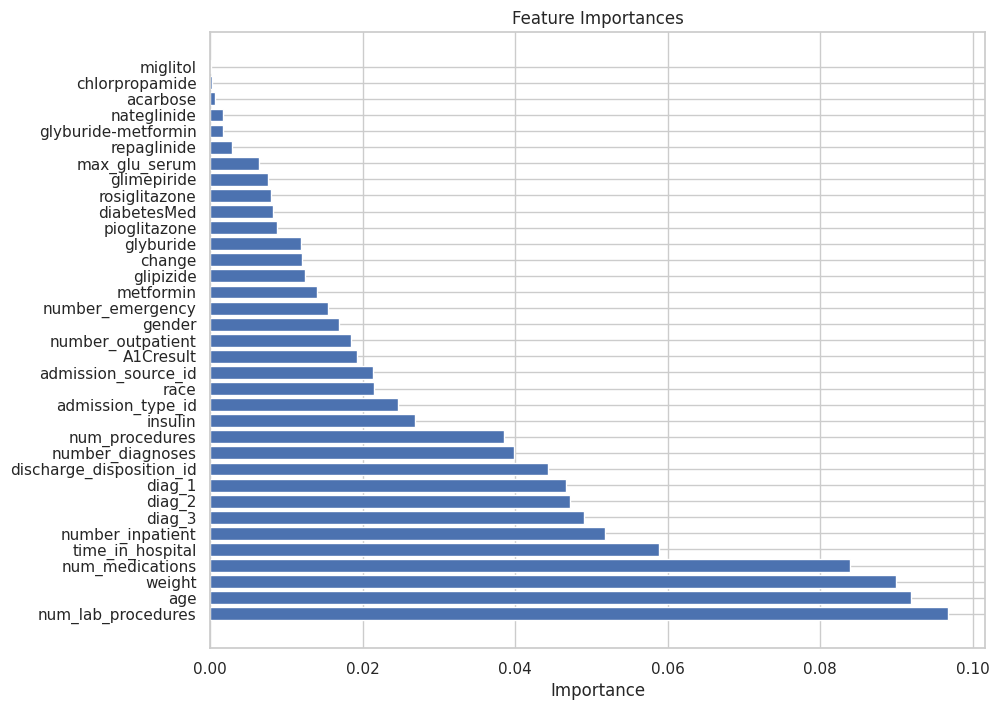

In [84]:
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(X, Y)

feature_importances = rfc_model.feature_importances_

# Create a barplot to visualize feature importances with variable attribute on y-axis
features = X.columns
indices = np.argsort(feature_importances)[::-1] # arrange the features by importance
plt.figure(figsize=(10,8))
plt.title("Feature Importances")
plt.barh(range(X.shape[1]), feature_importances[indices])
plt.yticks(range(X.shape[1]), features[indices])
plt.xlabel('Importance')
plt.show()



---


### Now, we Split the dataset into Training and Testing sets. By doing this we train multiple machine learning models on the training data and test the perfromance of each model on the testing data.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, Y, test_size=0.20, random_state=42)

In [86]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80192, 35), (20049, 35), (80192,), (20049,))

# Modelling and Model Tuning

### Now the task is to train multiple machine learning models. We divide them into 2 categories, they are as follows,
### 1] Classification Algorithms
### 2] Ensemble Learning Algorithms

# Classification Algorithms

# 1] Multinominal Logistic Regression

In [87]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [152]:
# predict the results on train set and obtain training accuracy
y_pred_logt = log_model.predict(X_train)

accuracy_logt = accuracy_score(y_train, y_pred_logt)
print(accuracy_logt)

0.6178421787709497


In [88]:
# predict the results on test set
y_pred_log = log_model.predict(X_test)

In [89]:
y_pred_log = y_pred_log.tolist()

In [90]:
print(y_pred_log)

[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 

In [130]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_log))
accuracy_log = accuracy_score(y_test, y_pred_log)
print(accuracy_log)

# Create the classification report
report = classification_report(y_test, y_pred_log)

print("Classification Report:\n", report)

[[8620 2261]
 [5348 3820]]
0.6204798244301462
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.79      0.69     10881
           1       0.63      0.42      0.50      9168

    accuracy                           0.62     20049
   macro avg       0.62      0.60      0.60     20049
weighted avg       0.62      0.62      0.61     20049



In [139]:
# Calculate the F1 score
f1_log = f1_score(y_test, y_pred_log)
f1_percentage = f1_log * 100

print("F1 Score:", f1_log)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.501016460095744
F1 Score (Percentage): 50.10%


# 2] Gaussian Naive Bayes

In [93]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [153]:
# predict the results on train set and obtain training accuracy
y_pred_gnbt = nb_model.predict(X_train)

accuracy_gnbt = accuracy_score(y_train, y_pred_gnbt)
print(accuracy_gnbt)

0.5846343774940144


In [94]:
# Predict the test set results
y_pred_gnb = nb_model.predict(X_test)

In [95]:
y_pred_gnb = y_pred_gnb.tolist()

In [96]:
print(y_pred_gnb)

[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 

In [131]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_gnb))
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(accuracy_gnb)

# Create the classification report
report = classification_report(y_test, y_pred_gnb)

print("Classification Report:\n", report)

[[9756 1125]
 [7104 2064]]
0.5895555888074219
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.90      0.70     10881
           1       0.65      0.23      0.33      9168

    accuracy                           0.59     20049
   macro avg       0.61      0.56      0.52     20049
weighted avg       0.61      0.59      0.53     20049



In [138]:
# Calculate the F1 score
f1_gnb = f1_score(y_test, y_pred_gnb)
f1_percentage = f1_gnb * 100

print("F1 Score:", f1_gnb)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))


F1 Score: 0.3340616654527798
F1 Score (Percentage): 33.41%


# 3] KNN Classifier

In [99]:
k = 5 # Number of neighbours to consider
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [155]:
# predict the results on train set and obtain training accuracy
y_pred_knnt = knn_model.predict(X_train)

accuracy_knnt = accuracy_score(y_train, y_pred_knnt)
print(accuracy_knnt)

0.7222416201117319


In [100]:
# Predict the test set results
y_pred_knn = knn_model.predict(X_test)

In [101]:
y_pred_knn = y_pred_knn.tolist()

In [102]:
print(y_pred_knn)

[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 

In [132]:
#Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_knn))
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(accuracy_knn)

# Generate the classification report
report = classification_report(y_test, y_pred_knn)

print("Classification Report:\n", report)

[[6903 3978]
 [4747 4421]]
0.5648162003092424
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.63      0.61     10881
           1       0.53      0.48      0.50      9168

    accuracy                           0.56     20049
   macro avg       0.56      0.56      0.56     20049
weighted avg       0.56      0.56      0.56     20049



In [140]:
# Calculate the F1 score
f1_knn = f1_score(y_test, y_pred_knn)
f1_percentage = f1_knn * 100

print("F1 Score:", f1_knn)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.5033301075880913
F1 Score (Percentage): 50.33%


# 4] Bernoulli Naive Bayes

In [124]:
bernoulli_model = BernoulliNB()
bernoulli_model.fit(X_train, y_train)

BernoulliNB()

In [156]:
# predict the results on train set and obtain training accuracy
y_pred_bnbt = bernoulli_model.predict(X_train)

accuracy_bnbt = accuracy_score(y_train, y_pred_bnbt)
print(accuracy_bnbt)

0.6132157821229051


In [125]:
y_pred_bnb = bernoulli_model.predict(X_test)

In [133]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_bnb))
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(accuracy_bnb)

# Create the classification report
report = classification_report(y_test, y_pred_bnb)

print("Classification Report:\n", report)

[[7724 3157]
 [4573 4595]]
0.6144446107037758
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.71      0.67     10881
           1       0.59      0.50      0.54      9168

    accuracy                           0.61     20049
   macro avg       0.61      0.61      0.60     20049
weighted avg       0.61      0.61      0.61     20049



In [141]:
# Calculate the F1 score
f1_bnb = f1_score(y_test, y_pred_bnb)
f1_percentage = f1_bnb * 100

print("F1 Score:", f1_bnb)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.543144208037825
F1 Score (Percentage): 54.31%


# 5] Decision Trees

In [177]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [178]:
# predict the results on train set and obtain training accuracy
y_pred_dtt = dt_model.predict(X_train)

accuracy_dtt = accuracy_score(y_train, y_pred_dtt)
print(accuracy_dtt)

1.0


In [163]:
y_pred_dt = dt_model.predict(X_test)

In [164]:
y_pred_dt = y_pred_dt.tolist()
print(y_pred_dt)

[0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 

In [165]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))
print(accuracy_score(y_test, y_pred_dt))

# Create the classification report
report = classification_report(y_test, y_pred_dt)

print("Classification Report:\n", report)

[[6383 4498]
 [4266 4902]]
0.5628709661329742
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.59      0.59     10881
           1       0.52      0.53      0.53      9168

    accuracy                           0.56     20049
   macro avg       0.56      0.56      0.56     20049
weighted avg       0.56      0.56      0.56     20049



### Hypertuning the Decision Tree model

In [166]:
dt_model = DecisionTreeClassifier(random_state=42)

# Define the parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Display the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)



Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [168]:
# Make predictions on the test set using the best model
best_dt_model = grid_search.best_estimator_
y_pred_dtm = best_dt_model.predict(X_test)


# Calculate the accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dtm)
print("Accuracy:", accuracy_dt)
print(classification_report(y_test, y_pred_dtm))

Accuracy: 0.6309042845029678
              precision    recall  f1-score   support

           0       0.64      0.73      0.68     10881
           1       0.61      0.52      0.56      9168

    accuracy                           0.63     20049
   macro avg       0.63      0.62      0.62     20049
weighted avg       0.63      0.63      0.63     20049



In [142]:
# Calculate the F1 score
f1_dt = f1_score(y_test, y_pred_dtm)
f1_percentage = f1_dt * 100

print("F1 Score:", f1_dt)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.5620783524677477
F1 Score (Percentage): 56.21%


# Ensemble Learning Algorithms

# 1] Random Forest

In [179]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [180]:
# predict the results on train set and obtain training accuracy
y_pred_rft = rf_model.predict(X_train)

accuracy_rft = accuracy_score(y_train, y_pred_rft)
print(accuracy_rft)

1.0


In [113]:
y_pred_rf = rf_model.predict(X_test)

In [135]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(accuracy_rf)

# Create the classification report
report = classification_report(y_test, y_pred_rf)

print("Classification Report:\n", report)

[[7918 2963]
 [4345 4823]]
0.6354930420469849
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.73      0.68     10881
           1       0.62      0.53      0.57      9168

    accuracy                           0.64     20049
   macro avg       0.63      0.63      0.63     20049
weighted avg       0.63      0.64      0.63     20049



In [143]:
# Calculate the F1 score
f1_rf = f1_score(y_test, y_pred_rf)
f1_percentage = f1_rf * 100

print("F1 Score:", f1_rf)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.5689512799339389
F1 Score (Percentage): 56.90%


# 2] XGBoost Classifier

In [172]:
xgb_model = xgb.XGBClassifier(use_label_encoder = False, eval_metric='mlogloss', objective='multi:softmax', num_class=3, seed=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [173]:
# predict the results on train set and obtain training accuracy
y_pred_xgbt = xgb_model.predict(X_train)

accuracy_xgbt = accuracy_score(y_train, y_pred_xgbt)
print(accuracy_xgbt)

0.7075518754988028


In [117]:
y_pred_xgb = xgb_model.predict(X_test)

In [144]:
# Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(accuracy_xgb)

# Create the classification report
report = classification_report(y_test, y_pred_xgb)

print("Classification Report:\n", report)

[[7696 3185]
 [4031 5137]]
0.6400817995910021
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.71      0.68     10881
           1       0.62      0.56      0.59      9168

    accuracy                           0.64     20049
   macro avg       0.64      0.63      0.63     20049
weighted avg       0.64      0.64      0.64     20049



In [145]:
# Calculate the F1 score
f1_xgb = f1_score(y_test, y_pred_xgb)
f1_percentage = f1_xgb * 100

print("F1 Score:", f1_xgb)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))


F1 Score: 0.5874213836477987
F1 Score (Percentage): 58.74%


#3] ADABoost (Adaptive Boosting) Classifier

In [174]:
adab_model = AdaBoostClassifier(n_estimators=200, random_state=42)

adab_model.fit(X_train, y_train)



AdaBoostClassifier(n_estimators=200, random_state=42)

In [175]:
# predict the results on train set and obtain training accuracy
y_pred_adabt = adab_model.predict(X_train)

accuracy_adabt = accuracy_score(y_train, y_pred_adabt)
print(accuracy_adabt)

0.6379314644852354


In [121]:
y_pred_adab = adab_model.predict(X_test)

In [146]:
#Evaluate the model performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_adab))
accuracy_adab = accuracy_score(y_test, y_pred_adab)
print(accuracy_adab)

# Generate the classification report
report = classification_report(y_test, y_pred_adab)

print("Classification Report:\n", report)

[[8261 2620]
 [4639 4529]]
0.637937054217168
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.76      0.69     10881
           1       0.63      0.49      0.56      9168

    accuracy                           0.64     20049
   macro avg       0.64      0.63      0.62     20049
weighted avg       0.64      0.64      0.63     20049



In [147]:
# Calculate the F1 score
f1_adab = f1_score(y_test, y_pred_adab)
f1_percentage = f1_adab * 100

print("F1 Score:", f1_adab)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.5551265551265551
F1 Score (Percentage): 55.51%


# Model Perfromance Comparison and Conclusion

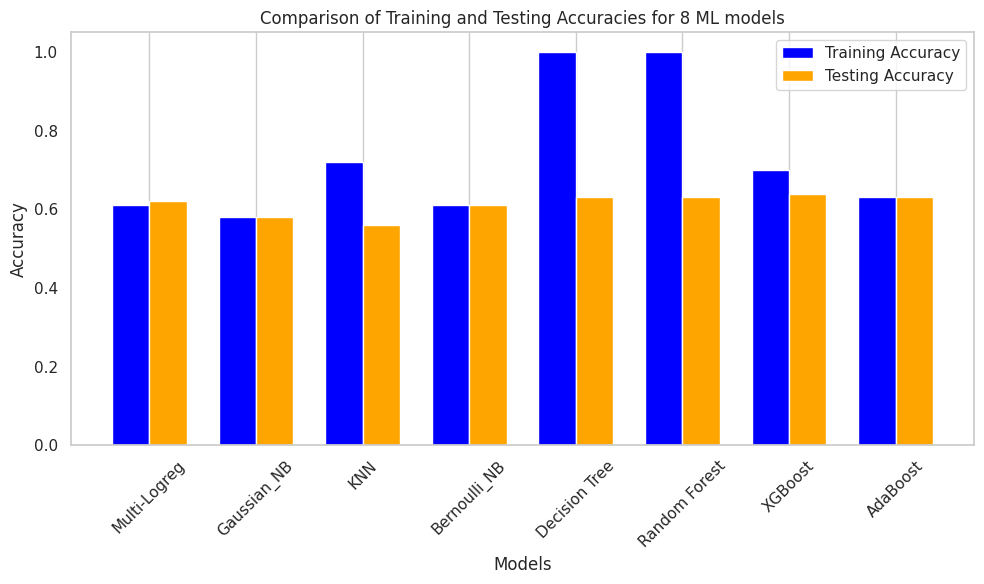

In [183]:

# Define the models and their accuracies
models = ['Multi-Logreg', 'Gaussian_NB', 'KNN', 'Bernoulli_NB', 'Decision Tree', 'Random Forest', 'XGBoost', 'AdaBoost']
training_accuracies = [0.61, 0.58, 0.72, 0.61, 1.0, 1.0, 0.70, 0.63]  # Example training accuracies
testing_accuracies = [0.62, 0.58, 0.56, 0.61, 0.63, 0.63, 0.64, 0.63]    # Example testing accuracies
bar_width = 0.35
index = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(index, training_accuracies, bar_width, label='Training Accuracy', color='blue')
plt.bar(index + bar_width, testing_accuracies, bar_width, label='Testing Accuracy', color='orange')

# Mention the appropriate labels
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Training and Testing Accuracies for 8 ML models')
plt.xticks(index + bar_width / 2, models, rotation=45)
plt.grid(axis='y')
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


### By visualizing the above graph, we can observe many things. Here we are comparing the Training and Testing accuracy of 8 ML models. We can observe that there is some sort of overfitting in training accuracy for Decision Tree and Random Forest model. But when we compare the accuracies of Multi-Logreg, Gaussian_NB, Bernoulli_NB, XGBoost and AdaBoost we can notice that both training and testing accuracy are very similar. This means that the model is perfroming well on both train and test data. So therefore we cann tell that the model has learnt the underlying patterns in the training data and is generalizing well to new or unseen data.


---



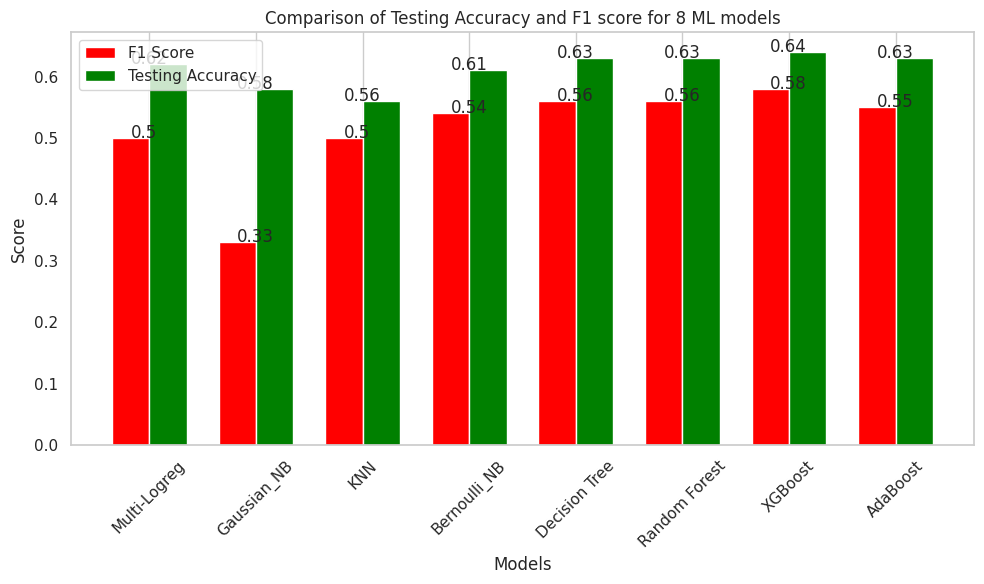

In [189]:
# Define the models and their accuracies

# function to add value labels
def addlabels(f1_scores,testing_accuracies):
    for i in range(len(f1_scores)):
        plt.text(i,testing_accuracies[i],testing_accuracies[i])
        plt.text(i,f1_scores[i],f1_scores[i])

models = ['Multi-Logreg', 'Gaussian_NB', 'KNN', 'Bernoulli_NB', 'Decision Tree', 'Random Forest', 'XGBoost', 'AdaBoost']
f1_scores = [0.50, 0.33, 0.50, 0.54, 0.56, 0.56, 0.58, 0.55]  # Example training accuracies
testing_accuracies = [0.62, 0.58, 0.56, 0.61, 0.63, 0.63, 0.64, 0.63]    # Example testing accuracies
bar_width = 0.35
index = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(index, f1_scores, bar_width, label='F1 Score', color='red')
plt.bar(index + bar_width, testing_accuracies, bar_width, label='Testing Accuracy', color='green')
addlabels(f1_scores, testing_accuracies)

# Mention the appropriate labels
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Testing Accuracy and F1 score for 8 ML models')
plt.xticks(index + bar_width / 2, models, rotation=45)
plt.grid(axis='y')
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

### Here we compare the testing accuracy and f1 scores, finally we can conclude that the best performing model, when compared with others is **XGBoost** as it has the highest testing accuracy of 0.64 (64%) and the highest f1 score of 0.58, since XGBoost refers to xtreme gradient boosting, it learns by assigning high weights to weak learners and finally imporves the overall accuracy of the model.

****************************************************************************